# Zadanie Pipline

Wybierz zbiór danych z tych, które wykorzystywane były w module o regresji lub klasyfikacji. Dla któregoś z tych zbiorów stwórz Pipeline, w którym zawrzesz proces przygotowania danych i naucz nowy model, porównując go z tymi stworzonymi w tamtych modułach.

## Import bibliotek i danych

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score, accuracy_score, precision_score, recall_score

dataset = pd.read_csv('penguins.csv')

Lista modeli jakie zostaną użyte.

In [2]:
modele = [
    ("Logistic Regression", LogisticRegression(max_iter=1000, random_state=42)),
    ("Decision Tree",       DecisionTreeClassifier(random_state=42)),
    ("Random Forest",       RandomForestClassifier(random_state=42)),
    ("AdaBoost",            AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1, random_state=42), n_estimators=50, random_state=42)),
    ("SVM",                 SVC(probability=True, random_state=42)),
    ("KNN",                 KNeighborsClassifier())
]

Funkcja wyliczająca metryki dla każdego modelu i zapisująca je do DF

In [3]:
def calculate_metrics(model, name, X_checked, y_checked, metrics_df, models_list, names_list, proba_list, cv_mean=None, cv_std=None):
    predictions = model.predict(X_checked)
    predictions_proba = model.predict_proba(X_checked)
    
    models_list.append(model)
    names_list.append(name)
    proba_list.append(predictions_proba)
    
    # ==================== METRYKI ====================
    # Zapis metryk
    f1_metric = f1_score(y_checked, predictions, average='macro')
    auc_metric = roc_auc_score(y_checked, predictions_proba, multi_class='ovr')
    acc_metric = accuracy_score(y_checked, predictions)
    prec_metric = precision_score(y_checked, predictions, average='macro')
    rec_metric = recall_score(y_checked, predictions, average='macro')
    
    new_row = pd.DataFrame([{
        'Model': name, 
        'Accuracy': acc_metric,
        'Precision': prec_metric,
        'Recall': rec_metric,
        'F1_score': f1_metric, 
        'AUC': auc_metric,
        'CV_Accuracy_Mean': cv_mean,
        'CV_Accuracy_Std': cv_std
    }])
    updated_df = pd.concat([metrics_df, new_row], ignore_index=True)
    return updated_df
    



In [4]:
features = ['CulmenLength','CulmenDepth','FlipperLength','BodyMass']
target = 'Species'

In [5]:
dataset = dataset.dropna(how='all')
dataset = dataset.dropna(subset=['Species'])

podział na zbiory testowe i treningowe

In [6]:

X, y = dataset[features], dataset[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

Tworzenie piplinu

In [7]:
num_preparation = Pipeline(steps=[
    ('fill_missings', SimpleImputer(strategy='mean')),
    ('polynomial_features', PolynomialFeatures(degree=3)),
    ('scaler_1', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('scaler_2', StandardScaler())
])

data_preparation = ColumnTransformer(transformers=[('numeric_preprocessing', num_preparation, features),])

pętla do uczenia wszystkich modeli z listy

In [11]:
metrics_dataframe = pd.DataFrame(columns=['Model', 'F1_score', 'AUC'])
models = []
models_names = []
predictions_proba_list = []


for nazwa_modelu, obiekt_modelu in modele:
    
    aktualny_pipeline = Pipeline(steps=[('preprocessor', data_preparation), (nazwa_modelu, obiekt_modelu)])
    scores = cross_val_score(aktualny_pipeline, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    aktualny_pipeline.fit(X_train, y_train)
    
    metrics_dataframe = calculate_metrics(
        model=aktualny_pipeline, 
        name=nazwa_modelu, 
        X_checked=X_test, 
        y_checked=y_test,
        metrics_df=metrics_dataframe,
        models_list=models,
        names_list=models_names,
        proba_list=predictions_proba_list,
        cv_mean=scores.mean(),
        cv_std=scores.std()
    )

Wykres przedtswaiajcy dokładność modeli.

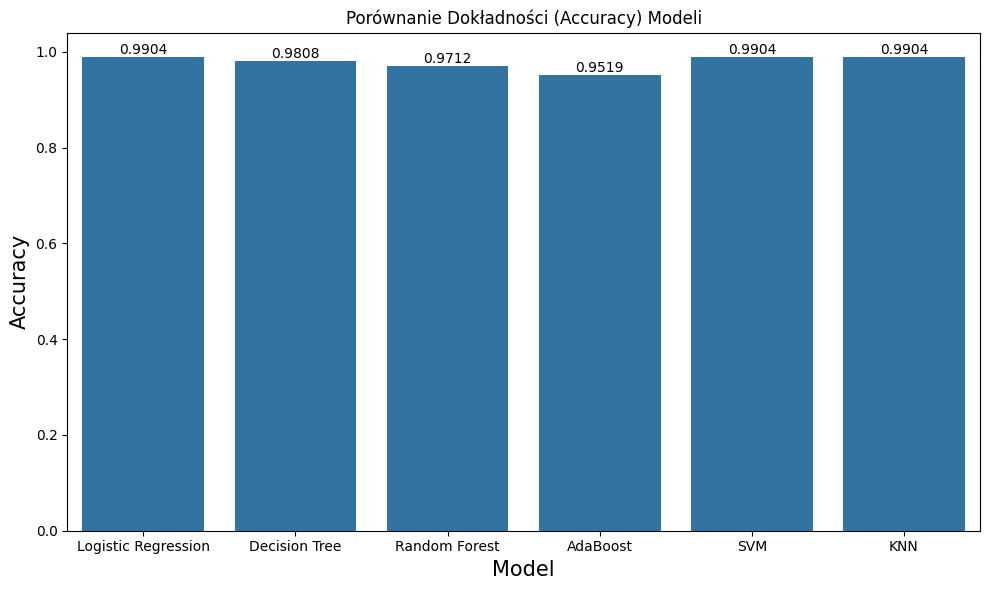

In [10]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=metrics_dataframe, x='Model', y='Accuracy')
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f')

plt.title('Porównanie Dokładności (Accuracy) Modeli')
plt.ylabel('Accuracy', fontsize=15)
plt.xlabel('Model', fontsize=15)
plt.tight_layout()
plt.show()

Względem zadania z modułu 14 widzimy znaczącą poprawę wyników prawie wszystkich modeli (oprócz AdaBoost). Ciekawe jest to że w tym wypadku pojedyńcze drzewo poradziło sobie lepiej od lasu i bardziej zaawansowanego modelu AdaBoost, spowodowane jest to wykorzystaniem algorytmu PCA w piplinie który utrudnił zadanie modelom Random forest oreaz AdaBoost, powodując overfitting. Potwierdza się tutaj fakt że skomplikowane modele nie zawsze i nie na każdych zbiorach danych będą dawać wyniki lepsze nawet od najprostszej regresji liniowej. 

In [13]:
display(metrics_dataframe)

,Model,F1_score,AUC,Accuracy,Precision,Recall,CV_Accuracy_Mean,CV_Accuracy_Std
0,Logistic Regression,0.988286,1.0,0.990385,0.992908,0.984127,0.987500,0.010206
1,Decision Tree,0.975305,0.978766,0.980769,0.984136,0.968254,0.929167,0.042898
2,Random Forest,0.962003,0.998448,0.971154,0.975814,0.952381,0.966667,0.036324
3,AdaBoost,0.939589,0.976691,0.951923,0.942165,0.937888,0.945833,0.036324
4,SVM,0.988286,1.0,0.990385,0.992908,0.984127,0.983333,0.015590
5,KNN,0.988286,0.999938,0.990385,0.992908,0.984127,0.975000,0.008333


Zgodnie z uwagą dodałem walidacje krzyżową i celowo nie zmieniam opisu z komurki wyżej gdzie błędnie interpretowałem wyniki po to by pamiętać że nie wolno ślepo wierzyć wynikom bez dokładnego ich oprzeanalizowania. Drzewo osiągneło tak dobry wynik jedynie z powodu "szczęśliwego" doboru danych. Wbrew temu co pisałem drzewo jest najgorszym modelelm dla tego zbioru. Nie dość że średnia "Accuracy" z walidacji kżyżowej jest najniższa to dodatkowo odchylenie jest największe, co oznacza że model jest bardzo niestabilny i wrażliwy na zmiany podziału danych. 